### Final project
## Customer Service Request Analysis

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import kruskal

In [2]:
df = pd.read_csv("311_Service_Requests.csv")

C:\Users\meets\AppData\Local\Temp\ipykernel_1772\3213624665.py:1: DtypeWarning: Columns (48,49) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv("311_Service_Requests.csv")


In [3]:
print(df.shape)          # Shape of dataset
print(df.columns)        # Column names
print(df.head())         # First 5 rows
print(df.info())         # Dataset info

(364558, 53)
Index(['Unique Key', 'Created Date', 'Closed Date', 'Agency', 'Agency Name',
       'Complaint Type', 'Descriptor', 'Location Type', 'Incident Zip',
       'Incident Address', 'Street Name', 'Cross Street 1', 'Cross Street 2',
       'Intersection Street 1', 'Intersection Street 2', 'Address Type',
       'City', 'Landmark', 'Facility Type', 'Status', 'Due Date',
       'Resolution Description', 'Resolution Action Updated Date',
       'Community Board', 'Borough', 'X Coordinate (State Plane)',
       'Y Coordinate (State Plane)', 'Park Facility Name', 'Park Borough',
       'School Name', 'School Number', 'School Region', 'School Code',
       'School Phone Number', 'School Address', 'School City', 'School State',
       'School Zip', 'School Not Found', 'School or Citywide Complaint',
       'Vehicle Type', 'Taxi Company Borough', 'Taxi Pick Up Location',
       'Bridge Highway Name', 'Bridge Highway Direction', 'Road Ramp',
       'Bridge Highway Segment', 'Garage Lot N

In [4]:
print(df.isnull().sum())

Unique Key                             0
Created Date                           0
Closed Date                         2381
Agency                                 0
Agency Name                            0
Complaint Type                         0
Descriptor                          6501
Location Type                        133
Incident Zip                        2998
Incident Address                   51699
Street Name                        51699
Cross Street 1                     57188
Cross Street 2                     57805
Intersection Street 1             313438
Intersection Street 2             314046
Address Type                        3252
City                                2997
Landmark                          364183
Facility Type                       2389
Status                                 0
Due Date                               3
Resolution Description                 0
Resolution Action Updated Date      2402
Community Board                        0
Borough         

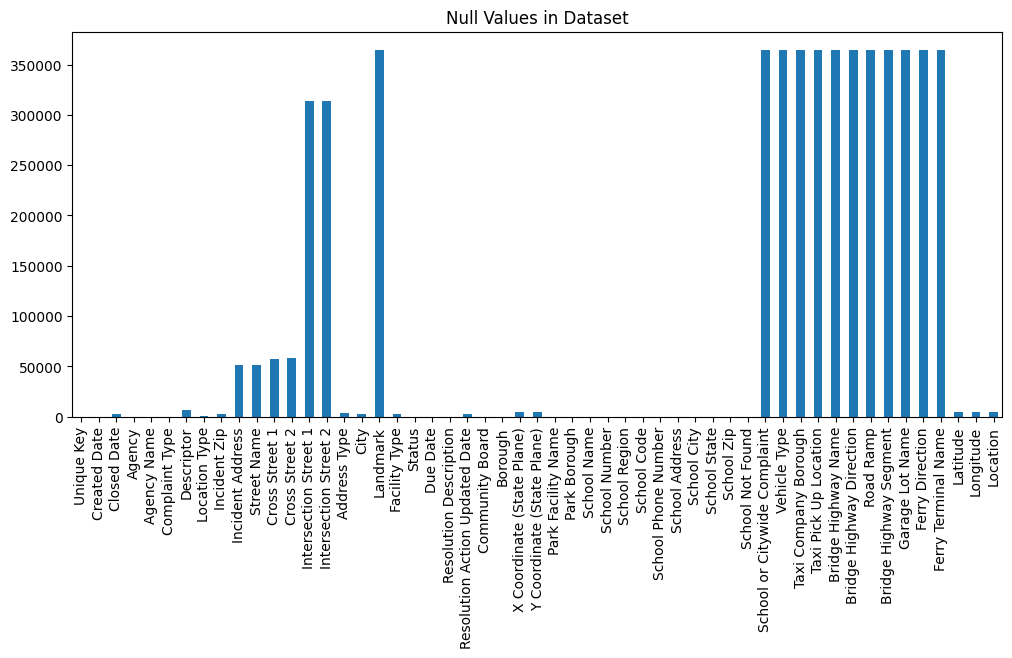

In [5]:
df.isnull().sum().plot(kind='bar', figsize=(12,5))
plt.title("Null Values in Dataset")
plt.show()

In [9]:
df = df[df['Closed Date'].notnull()]

In [14]:
import pandas as pd

df['Created Date'] = pd.to_datetime(df['Created Date'], format="%m/%d/%Y %I:%M:%S %p")
df['Closed Date'] = pd.to_datetime(df['Closed Date'], format='mixed')


In [15]:
df['Created Date'] = pd.to_datetime(df['Created Date'])
df['Closed Date'] = pd.to_datetime(df['Closed Date'])

In [16]:
df['Request_Closing_Time'] = df['Closed Date'] - df['Created Date']

In [17]:
df['Request_Closing_Time'] = df['Request_Closing_Time'].dt.total_seconds()

In [18]:
df['City'].fillna("Unknown City", inplace=True)

In [19]:
print(df[['Complaint Type','City']].isnull().sum())

Complaint Type    0
City              0
dtype: int64


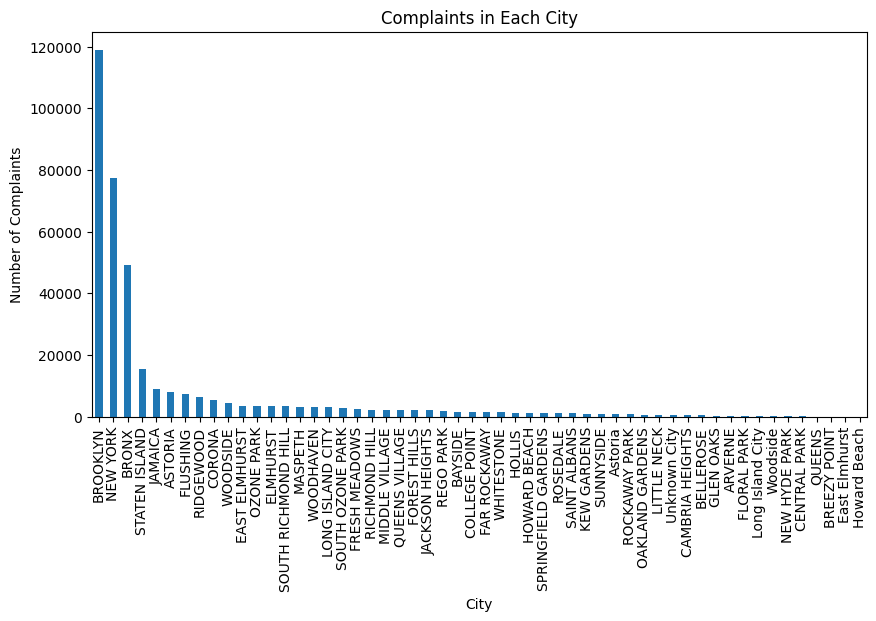

In [20]:
plt.figure(figsize=(10,5))
df['City'].value_counts().plot(kind='bar')
plt.title("Complaints in Each City")
plt.xlabel("City")
plt.ylabel("Number of Complaints")
plt.show()

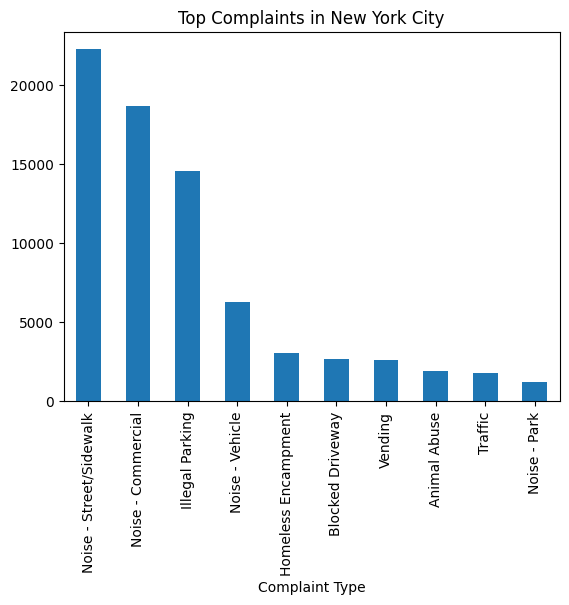

In [21]:
nyc = df[df['City'] == 'NEW YORK']

nyc['Complaint Type'].value_counts().head(10).plot(kind='bar')
plt.title("Top Complaints in New York City")
plt.show()

In [22]:
df_new = pd.crosstab(df['Complaint Type'], df['City'])
print(df_new.head())

City                       ARVERNE  ASTORIA  Astoria  BAYSIDE  BELLEROSE  \
Complaint Type                                                             
Agency Issues                    0        0        0        0          0   
Animal Abuse                    46      170        0       53         15   
Animal in a Park                 0        0        0        0          0   
Bike/Roller/Skate Chronic        0       16        0        0          1   
Blocked Driveway                50     3436      159      514        138   

City                       BREEZY POINT  BRONX  BROOKLYN  CAMBRIA HEIGHTS  \
Complaint Type                                                              
Agency Issues                         0      0         0                0   
Animal Abuse                          2   1971      3191               15   
Animal in a Park                      0      0         0                0   
Bike/Roller/Skate Chronic             0     22       124                0   
Block

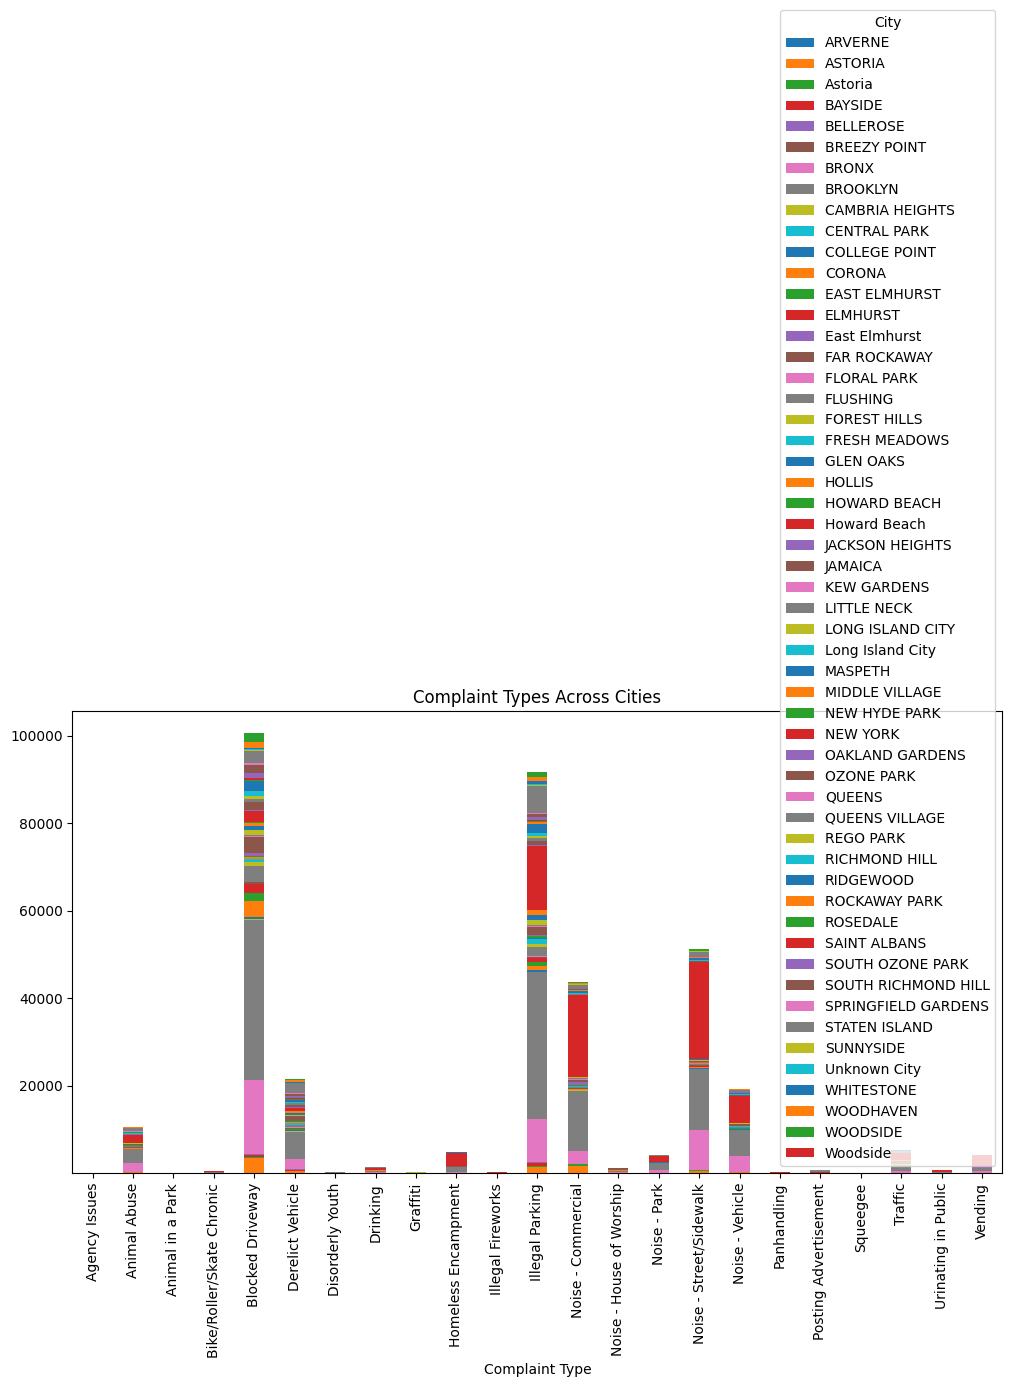

In [23]:
df_new.plot(kind='bar', stacked=True, figsize=(12,6))
plt.title("Complaint Types Across Cities")
plt.show()

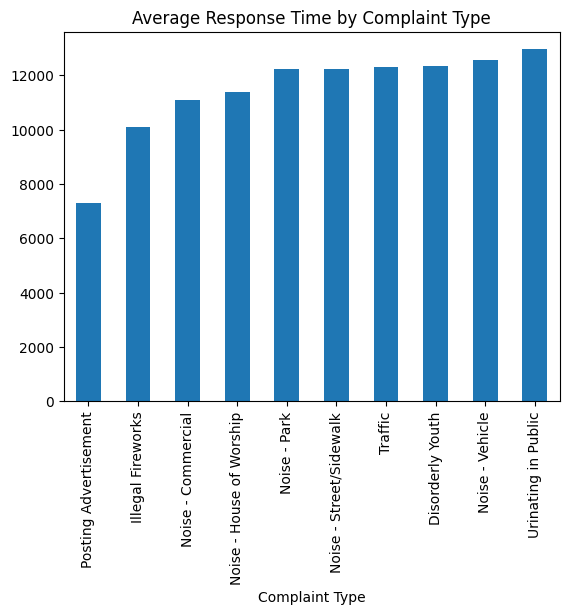

In [24]:
avg_time = df.groupby('Complaint Type')['Request_Closing_Time'].mean()

avg_time.sort_values().head(10).plot(kind='bar')
plt.title("Average Response Time by Complaint Type")
plt.show()

In [25]:
groups = []

for complaint in df['Complaint Type'].unique():
    groups.append(df[df['Complaint Type']==complaint]['Request_Closing_Time'])

In [26]:
stat, p = kruskal(*groups)

print("Kruskal Test Statistic:", stat)
print("P Value:", p)

Kruskal Test Statistic: 11988.190080116212
P Value: 0.0


In [27]:
alpha = 0.05

if p < alpha:
    print("Reject Null Hypothesis")
else:
    print("Fail to Reject Null Hypothesis")

Reject Null Hypothesis


In [28]:
print("Most common complaint:", df['Complaint Type'].value_counts().idxmax())
print("City with highest complaints:", df['City'].value_counts().idxmax())

Most common complaint: Blocked Driveway
City with highest complaints: BROOKLYN
